In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models, transforms
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

In [ ]:
class LensingDataset(Dataset):
    def __init__(self, root_dirs, transform=None):
        self.samples = []
        self.labels = []
        self.transform = transform
        self.class_map = {'no': 0, 'sphere': 1, 'vort': 2}

        for root_dir in root_dirs:
            for class_name, label in self.class_map.items():
                class_path = os.path.join(root_dir, class_name)
                for fname in os.listdir(class_path):
                    if fname.endswith('.npy'):
                        self.samples.append(os.path.join(class_path, fname))
                        self.labels.append(label)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img = np.load(self.samples[idx])  # (1, 150, 150)
        img = torch.tensor(img, dtype=torch.float32)
        if self.transform:
            img = self.transform(img)
        label = self.labels[idx]
        return img, label

full_dataset = LensingDataset(
    root_dirs=['/content/dataset/train', '/content/dataset/val']
)

train_size = int(0.9 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train: {train_size}, Test: {test_size}")

Train: 33750, Test: 3750


In [ ]:
class ConvergenceEstimator(nn.Module):
    """Small CNN to estimate convergence map κ from lensing image"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 16, 3, padding=1)
        self.conv4 = nn.Conv2d(16, 1, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.bn2 = nn.BatchNorm2d(32)
        self.bn3 = nn.BatchNorm2d(16)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        kappa = F.softplus(self.conv4(x))  # non-negative convergence
        return kappa


class PhysicsFeatureExtractor(nn.Module):
    """Extract physics-motivated features from convergence map using lensing equation"""
    def __init__(self):
        super().__init__()

    def compute_deflection_angles(self, kappa):
        """
        Compute deflection angles from convergence using Poisson equation.
        ∇²ψ = 2κ => solve in Fourier space => α = ∇ψ
        """
        batch_size, _, H, W = kappa.shape

        # Create frequency grids
        freq_y = torch.fft.fftfreq(H, device=kappa.device).reshape(-1, 1).repeat(1, W)
        freq_x = torch.fft.fftfreq(W, device=kappa.device).reshape(1, -1).repeat(H, 1)

        # Solve Poisson equation in Fourier space: ψ_hat = 2κ_hat / (k²)
        k_squared = (2 * np.pi * freq_x)**2 + (2 * np.pi * freq_y)**2
        k_squared[0, 0] = 1.0  # avoid division by zero

        kappa_hat = torch.fft.fft2(kappa.squeeze(1))
        psi_hat = 2 * kappa_hat / k_squared.unsqueeze(0)

        # Deflection angles: α = ∇ψ (gradient in Fourier space)
        alpha_x = torch.fft.ifft2(1j * 2 * np.pi * freq_x.unsqueeze(0) * psi_hat).real
        alpha_y = torch.fft.ifft2(1j * 2 * np.pi * freq_y.unsqueeze(0) * psi_hat).real

        return alpha_x, alpha_y

    def forward(self, kappa):
        alpha_x, alpha_y = self.compute_deflection_angles(kappa)

        # Deflection magnitude
        alpha_mag = torch.sqrt(alpha_x**2 + alpha_y**2 + 1e-8)

        # Physics features per sample
        features = []

        # Convergence statistics
        features.append(kappa.mean(dim=[1, 2, 3]))        # mean κ
        features.append(kappa.std(dim=[1, 2, 3]))         # std κ
        features.append(kappa.amax(dim=[1, 2, 3]))        # max κ

        # Deflection statistics
        features.append(alpha_mag.mean(dim=[1, 2]))        # mean deflection
        features.append(alpha_mag.std(dim=[1, 2]))         # deflection variance

        # Gradient energy of κ (high for substructure)
        kappa_dx = kappa[:, :, :, 1:] - kappa[:, :, :, :-1]
        kappa_dy = kappa[:, :, 1:, :] - kappa[:, :, :-1, :]
        grad_energy = (kappa_dx**2).mean(dim=[1, 2, 3]) + (kappa_dy**2).mean(dim=[1, 2, 3])
        features.append(grad_energy)

        return torch.stack(features, dim=1)  # (batch, 6)


class PhysicsInformedLensingClassifier(nn.Module):
    """
    Dual-branch classifier combining CNN features with physics-informed features
    derived from the gravitational lensing equation.
    """
    def __init__(self, num_classes=3):
        super().__init__()

        # Branch 1: CNN backbone
        self.resnet = models.resnet18(pretrained=True)
        self.resnet.fc = nn.Identity()  # remove final FC, outputs 512 features

        # Branch 2: Physics branch
        self.convergence_net = ConvergenceEstimator()
        self.physics_features = PhysicsFeatureExtractor()

        # Fusion classifier
        # 512 (ResNet) + 6 (physics features) = 518
        self.classifier = nn.Sequential(
            nn.Linear(518, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # CNN branch (needs 3-channel input)
        x_3ch = x.repeat(1, 3, 1, 1)
        x_resized = F.interpolate(x_3ch, size=(224, 224), mode='bilinear', align_corners=False)
        cnn_features = self.resnet(x_resized)  # (batch, 512)

        # Physics branch (works on original single-channel)
        kappa = self.convergence_net(x)  # estimated convergence map
        phys_features = self.physics_features(kappa)  # (batch, 6)

        # Fuse and classify
        combined = torch.cat([cnn_features, phys_features], dim=1)  # (batch, 518)
        output = self.classifier(combined)

        return output, kappa

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PhysicsInformedLensingClassifier().to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 74.6MB/s]


Model parameters: 11,253,028


In [ ]:
def physics_loss(kappa):
    """
    Physics-based regularization derived from lensing equation properties.
    """
    # 1. Smoothness: Total variation of convergence map
    tv_h = torch.abs(kappa[:, :, 1:, :] - kappa[:, :, :-1, :]).mean()
    tv_w = torch.abs(kappa[:, :, :, 1:] - kappa[:, :, :, :-1]).mean()
    smoothness_loss = tv_h + tv_w

    # 2. Poisson consistency: ∇²ψ = 2κ
    # Approximate Laplacian of kappa (should relate to mass density gradient)
    laplacian_kernel = torch.tensor([[0, 1, 0], [1, -4, 1], [0, 1, 0]],
                                     dtype=torch.float32, device=kappa.device).reshape(1, 1, 3, 3)
    laplacian_kappa = F.conv2d(kappa, laplacian_kernel, padding=1)
    poisson_loss = (laplacian_kappa**2).mean()

    return 0.5 * smoothness_loss + 0.5 * poisson_loss


# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
lambda_physics = 0.01  # physics loss weight

num_epochs = 25

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_cls_loss = 0.0
    running_phys_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs, kappa = model(images)

        # Combined loss
        cls_loss = criterion(outputs, labels)
        phys_loss = physics_loss(kappa)
        total_loss = cls_loss + lambda_physics * phys_loss

        total_loss.backward()
        optimizer.step()

        running_loss += total_loss.item()
        running_cls_loss += cls_loss.item()
        running_phys_loss += phys_loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if batch_idx % 50 == 0:
            print(f"Epoch {epoch+1} - Batch {batch_idx}/{len(train_loader)} "
                  f"- Loss: {total_loss.item():.4f} (cls: {cls_loss.item():.4f}, "
                  f"phys: {phys_loss.item():.4f})")

    scheduler.step()
    train_acc = 100. * correct / total
    avg_loss = running_loss / len(train_loader)
    avg_cls = running_cls_loss / len(train_loader)
    avg_phys = running_phys_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs} - Total Loss: {avg_loss:.4f} "
          f"(cls: {avg_cls:.4f}, phys: {avg_phys:.4f}) - Acc: {train_acc:.2f}%")
    print()

Epoch 1 - Batch 0/528 - Loss: 1.0769 (cls: 1.0750, phys: 0.1917)
Epoch 1 - Batch 50/528 - Loss: 1.0933 (cls: 1.0926, phys: 0.0642)
Epoch 1 - Batch 100/528 - Loss: 1.0978 (cls: 1.0974, phys: 0.0426)
Epoch 1 - Batch 150/528 - Loss: 0.9342 (cls: 0.9339, phys: 0.0322)
Epoch 1 - Batch 200/528 - Loss: 0.9059 (cls: 0.9057, phys: 0.0280)
Epoch 1 - Batch 250/528 - Loss: 0.7076 (cls: 0.7074, phys: 0.0242)
Epoch 1 - Batch 300/528 - Loss: 0.5635 (cls: 0.5633, phys: 0.0230)
Epoch 1 - Batch 350/528 - Loss: 0.5318 (cls: 0.5316, phys: 0.0213)
Epoch 1 - Batch 400/528 - Loss: 0.4658 (cls: 0.4656, phys: 0.0196)
Epoch 1 - Batch 450/528 - Loss: 0.5817 (cls: 0.5815, phys: 0.0182)
Epoch 1 - Batch 500/528 - Loss: 0.4874 (cls: 0.4873, phys: 0.0175)
Epoch 1/25 - Total Loss: 0.7615 (cls: 0.7612, phys: 0.0340) - Acc: 62.42%

Epoch 2 - Batch 0/528 - Loss: 0.4251 (cls: 0.4249, phys: 0.0170)
Epoch 2 - Batch 50/528 - Loss: 0.4964 (cls: 0.4962, phys: 0.0163)
Epoch 2 - Batch 100/528 - Loss: 0.3027 (cls: 0.3025, phys: 0

Class                       Test I AUC Test VII AUC     Change
No Substructure                 0.9857       0.9879 +   0.0022
Subhalo (sphere)                0.9623       0.9775 +   0.0152
Vortex                          0.9845       0.9919 +   0.0074


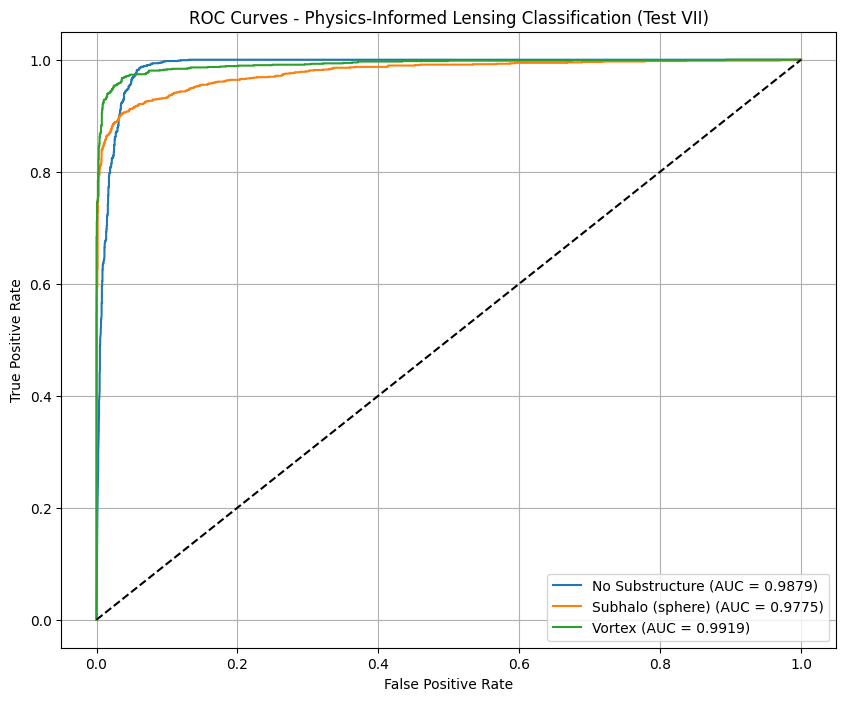


Macro AUC: 0.9858 (Baseline: 0.9775, Change: +0.0083)


In [ ]:
model.eval()
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs, _ = model(images)
        probs = torch.softmax(outputs, dim=1)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Baseline AUCs from Test I
baseline_aucs = {'No Substructure': 0.9857, 'Subhalo (sphere)': 0.9623, 'Vortex': 0.9845}

class_names = ['No Substructure', 'Subhalo (sphere)', 'Vortex']
plt.figure(figsize=(10, 8))

print("=" * 60)
print(f"{'Class':<25} {'Test I AUC':>12} {'Test VII AUC':>12} {'Change':>10}")
print("=" * 60)

for i, name in enumerate(class_names):
    binary_labels = (all_labels == i).astype(int)
    fpr, tpr, _ = roc_curve(binary_labels, all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    change = roc_auc - baseline_aucs[name]
    sign = "+" if change >= 0 else ""
    print(f"{name:<25} {baseline_aucs[name]:>12.4f} {roc_auc:>12.4f} {sign}{change:>9.4f}")
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Physics-Informed Lensing Classification (Test VII)')
plt.legend()
plt.grid(True)
plt.savefig('roc_curves_test7.png', dpi=150, bbox_inches='tight')
plt.show()

macro_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
baseline_macro = np.mean(list(baseline_aucs.values()))
print(f"\nMacro AUC: {macro_auc:.4f} (Baseline: {baseline_macro:.4f}, "
      f"Change: {'+' if macro_auc >= baseline_macro else ''}{macro_auc - baseline_macro:.4f})")

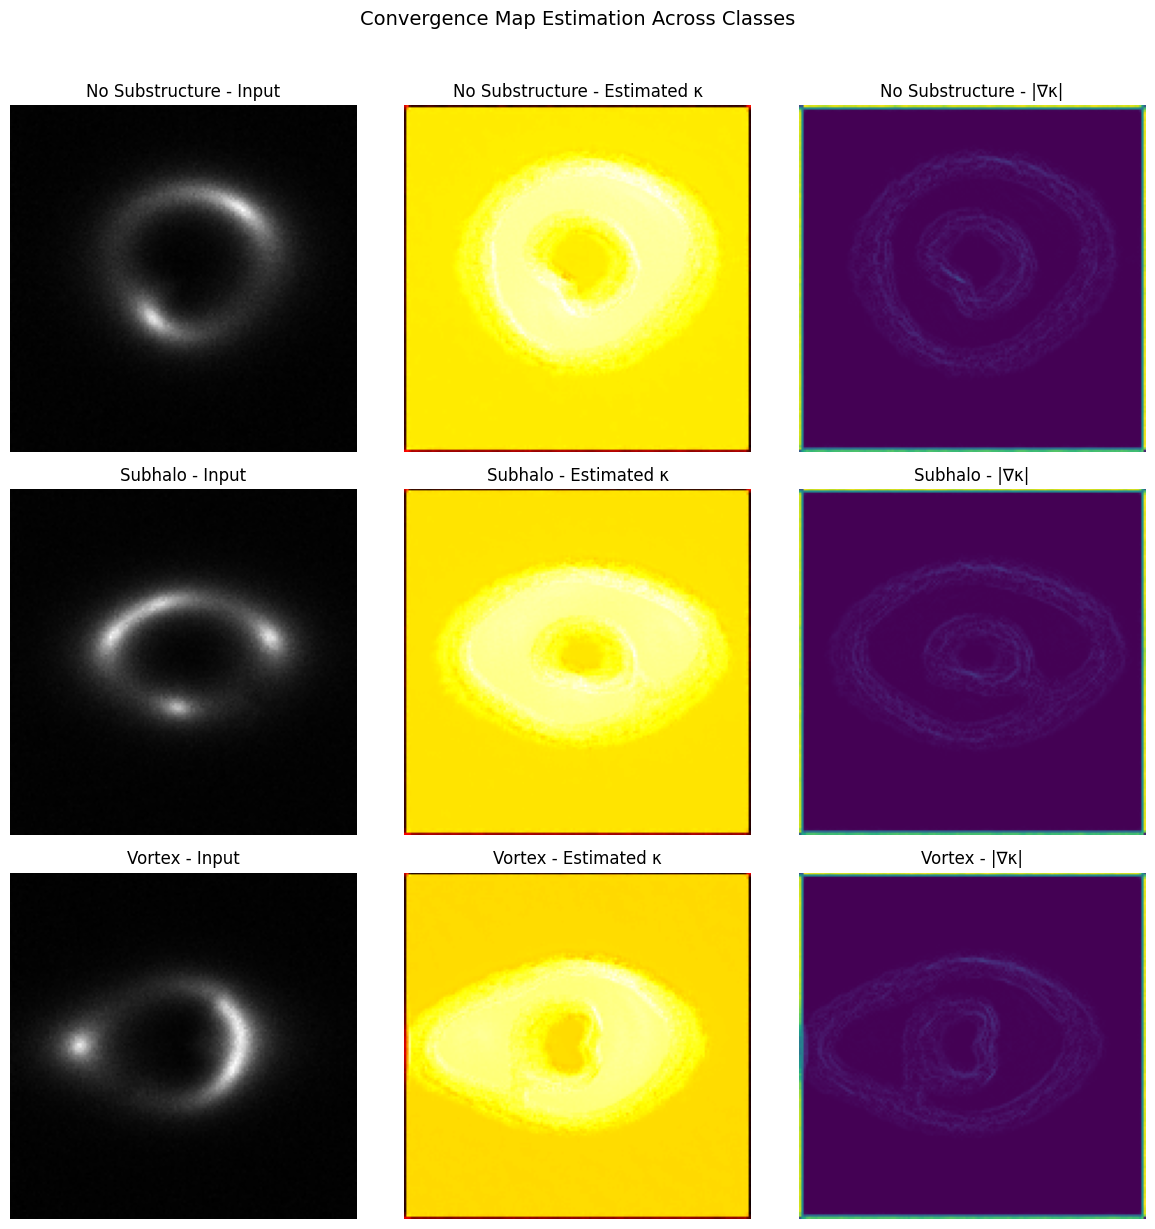

In [ ]:
# Visualize estimated convergence maps for each class
model.eval()
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
class_names_short = ['No Substructure', 'Subhalo', 'Vortex']

with torch.no_grad():
    for class_idx in range(3):
        # Find samples of this class from test set
        count = 0
        for images, labels in test_loader:
            for i in range(len(labels)):
                if labels[i].item() == class_idx and count < 1:
                    img = images[i:i+1].to(device)
                    _, kappa = model(img)

                    axes[class_idx, 0].imshow(images[i, 0].numpy(), cmap='gray')
                    axes[class_idx, 0].set_title(f'{class_names_short[class_idx]} - Input')
                    axes[class_idx, 0].axis('off')

                    axes[class_idx, 1].imshow(kappa[0, 0].cpu().numpy(), cmap='hot')
                    axes[class_idx, 1].set_title(f'{class_names_short[class_idx]} - Estimated κ')
                    axes[class_idx, 1].axis('off')

                    # Show gradient magnitude of kappa
                    k = kappa[0, 0].cpu().numpy()
                    grad_x = np.gradient(k, axis=1)
                    grad_y = np.gradient(k, axis=0)
                    grad_mag = np.sqrt(grad_x**2 + grad_y**2)
                    axes[class_idx, 2].imshow(grad_mag, cmap='viridis')
                    axes[class_idx, 2].set_title(f'{class_names_short[class_idx]} - |∇κ|')
                    axes[class_idx, 2].axis('off')

                    count += 1
            if count >= 1:
                break

plt.suptitle('Convergence Map Estimation Across Classes', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('convergence_maps_test7.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
torch.save(model.state_dict(), 'physics_informed_lensing_classifier.pth')
print("Model saved!")

Model saved!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')